# Model Complexity and Overfitting

**Overview**
In this exercise you will experiment with the impact of model complexity (higher order polynomial) and how it relates to Occam's Razor. 


<article class="message">
    <div class="message-body">
        <strong>List of tasks</strong>
        <ul style="list-style: none;">
            <li>
            <a href="#poly_re">Task 1:  Polynomial regression</a>
            </li>
            <li>
            <a href="#occam_train">Task 2: Train and evaluate linear models with po…</a>
            </li>
            <li>
            <a href="#plot_results">Task 3: Plot the polynomials (models)</a>
            </li>
            <li>
            <a href="#reflection">Task 4: Reflection</a>
            </li>
            <li>
            <a href="#Different_data_func">Task 5: Changing the data generating function</a>
            </li>
        </ul>
    </div>
</article>

<div style="float: right; width: 50%; justify-content: start" class="block is-clearfix">

<div class="has-text-centered">
<figure class="image is-inline-block" >

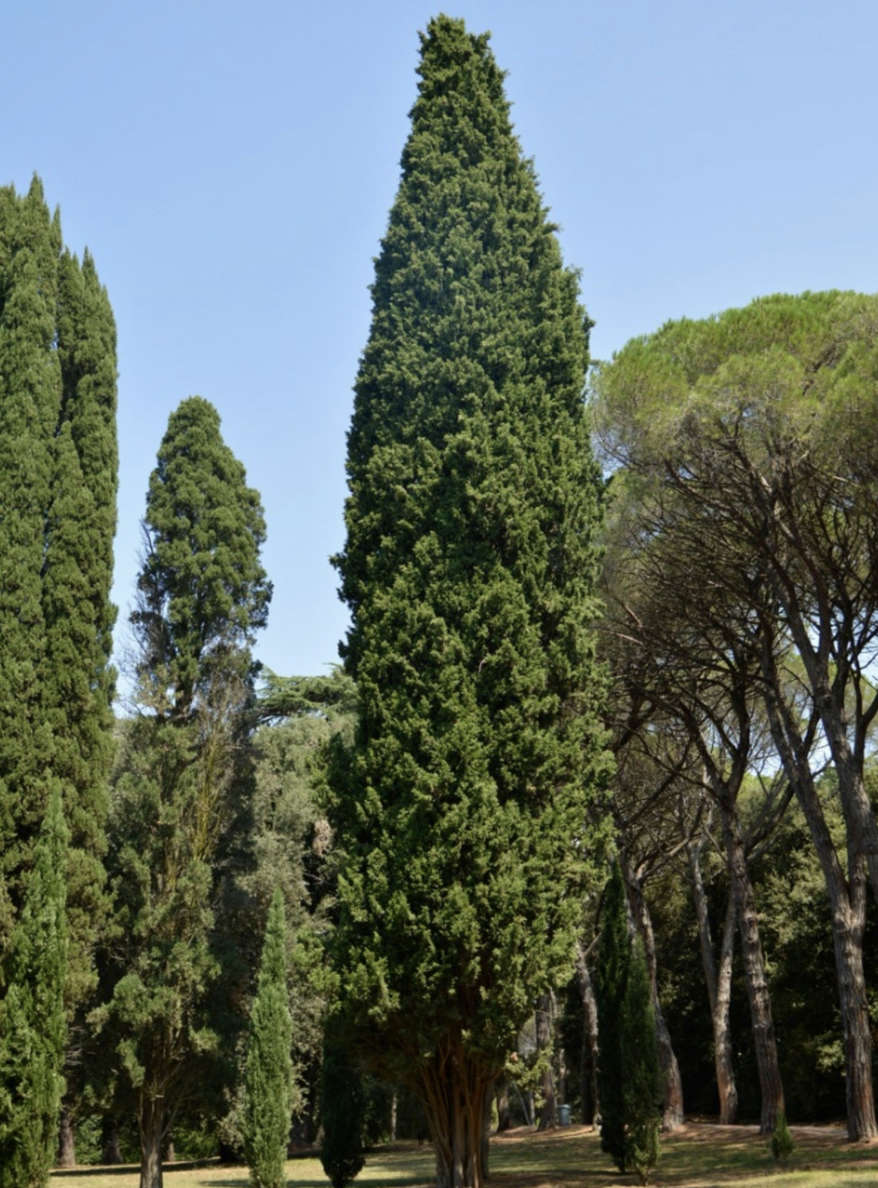


</figure>
</div>


</div>

This exercise is about making a regression model to predict the growth of Thuja Green Giant trees. You have to help the scientists decide which polynomial order best represents the training data to estimate future growth. To determine the optimal fit (model parameters), another group of researchers have provided you with  observation of height of their Thuja Green Giant trees from years later than currently observed by your team (`X_test`
 and `y_test`
). You will use this to choose the optimal model representing the growth of the Thuja Green Giant.
## Data
The following cell constructs and shows the data for the exercise. The data simulates growth (in meters) of one of the fastest growing trees, the Thuja Green Giant, each year. Scientists have observed and reported the growth of the tree for 7 years (`X_train`
 and `y_train`
), and now want to predict the future growth. 
The objective is to assist in making predictions based on this data. Additional data from another group has been provided to validate the hypothesis.
The scientists assume a polynomial relationship. 


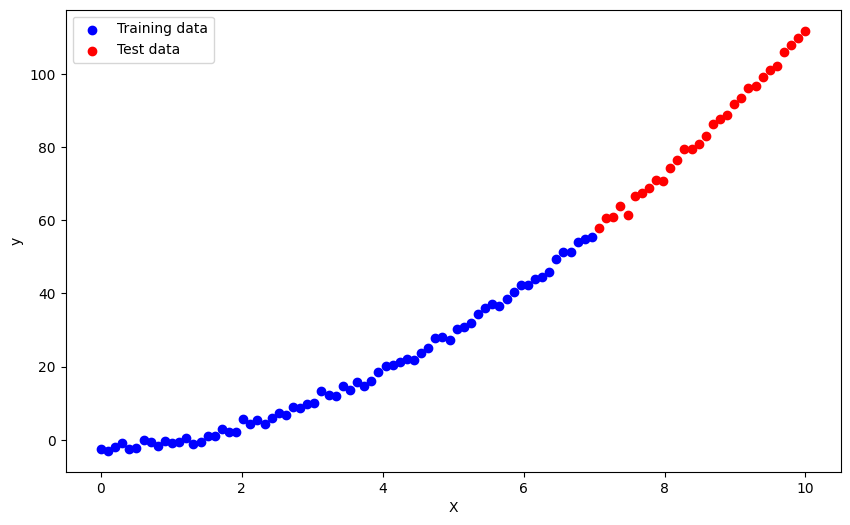

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
# Set a random seed for reproducibility
np.random.seed(42)

# Generate synthetic data
n_samples = 100
X = np.linspace(0, 10, n_samples).reshape(-1, 1)
y_true = X.ravel() ** 2 + 1.5 * X.ravel() - 3 #1.5 * X.ravel() + 0.2
noise = np.random.normal(0, 1, n_samples)
y = y_true + noise

# Split the data into training and test sets
split_index = int(0.7 * n_samples)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]


# Plot the results
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', label='Training data')
plt.scatter(X_test, y_test, color='red', label='Test data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

In [50]:
import os
os.chdir('..')
from utils import *


---
**Task 1 (easy):  Polynomial regression👩‍💻**
1. In this exercise you may reuse polynomial regression using least squares
 from the previous exercise, or use the `PolynomialFeatures()`
 method from the [scikit-learn library](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html)
 to implement the `polynomial_regression()`
 method in the cell below. 


---

In [51]:
def polynomial_regression(X, y, degree):
    """
    Create and train a model of desired order and use it to predict the growth of the trees.

    :param X: Vector of combined observed years).
    :param y: Vector of combined observed height.
    :param degree: Degree of the model.
    
    :return: Vector containing prediction for training data, predictor
    """
    ds = processDataset(np.array([X, y]).T)
    ds.get_design_matrix(degree)
    ds.get_weights()
    return (ds.predict(X), ds)

In [52]:
polynomial_regression(X_train[:,0], y_train, 1)

(array([-1.11586732e+01, -1.03018386e+01, -9.44500396e+00, -8.58816936e+00,
        -7.73133475e+00, -6.87450014e+00, -6.01766553e+00, -5.16083092e+00,
        -4.30399631e+00, -3.44716170e+00, -2.59032709e+00, -1.73349249e+00,
        -8.76657876e-01, -1.98232676e-02,  8.37011341e-01,  1.69384595e+00,
         2.55068056e+00,  3.40751517e+00,  4.26434978e+00,  5.12118438e+00,
         5.97801899e+00,  6.83485360e+00,  7.69168821e+00,  8.54852282e+00,
         9.40535743e+00,  1.02621920e+01,  1.11190266e+01,  1.19758613e+01,
         1.28326959e+01,  1.36895305e+01,  1.45463651e+01,  1.54031997e+01,
         1.62600343e+01,  1.71168689e+01,  1.79737035e+01,  1.88305381e+01,
         1.96873727e+01,  2.05442073e+01,  2.14010420e+01,  2.22578766e+01,
         2.31147112e+01,  2.39715458e+01,  2.48283804e+01,  2.56852150e+01,
         2.65420496e+01,  2.73988842e+01,  2.82557188e+01,  2.91125534e+01,
         2.99693880e+01,  3.08262226e+01,  3.16830573e+01,  3.25398919e+01,
         3.3


---
**Task 2 (easy): Train and evaluate linear models with polynomial features👩‍💻**
1. Use the function `polynomial_regression`
 to perform polynomial regression for each order defined in the `degrees`
 variable and predict the outcome for both the test and training data. 
2. Implement the function `compute_mse`
 that based on the predictions of a model and the ground truth targets returns the _mean-squared-error_.


$$ MSE = \frac{1}{m}\sum_{i=1}^{m}(f_{\mathbf{w}}(x_{i})-y_{i})^2$$

**Hint**
You may save some time by modifying the implementation of the `rmse`
 function from the previous exercise.

3. For each polynomial model calculate the _mean-squared-error_ for both the training and test data (use `polynomial_regression`
 and `compute_mse`
).


---

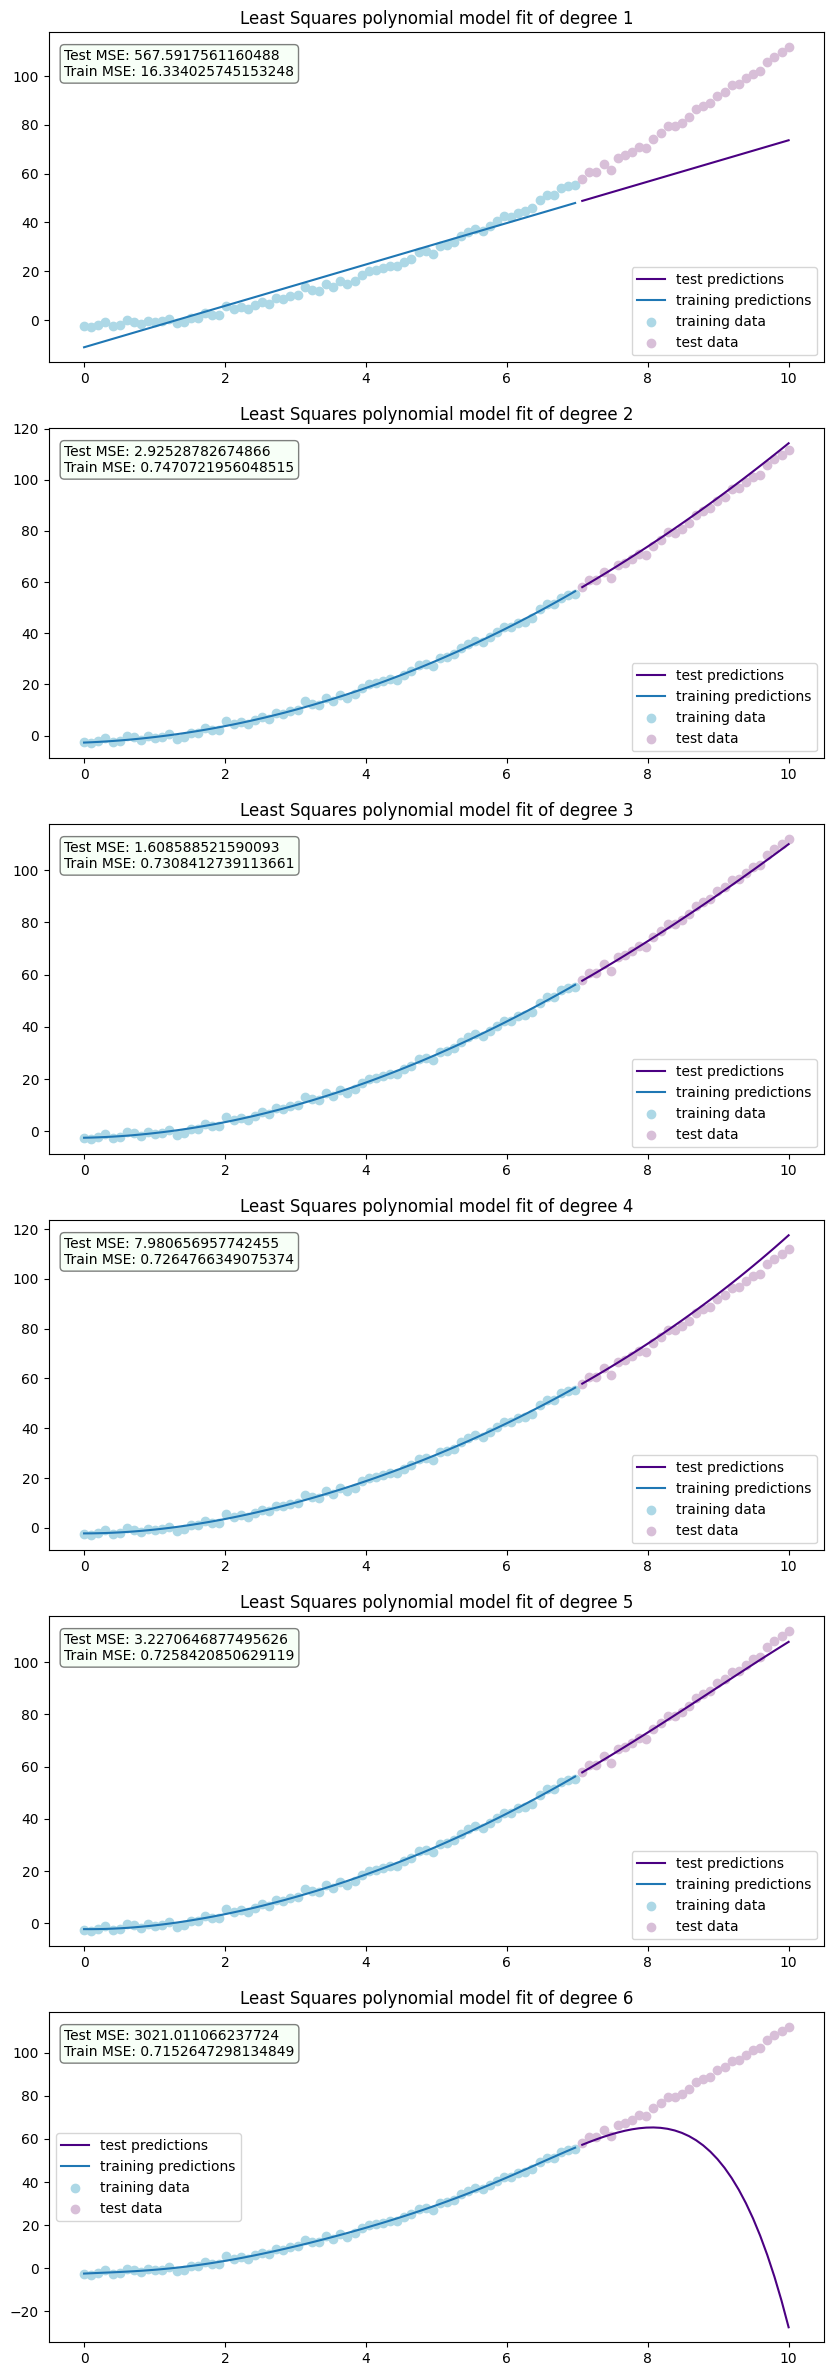

In [53]:
def compute_mse(y_true, y_pred):
    """Compute Mean Squared Error between true and predicted values."""
    return Eval().mse(y_true, y_pred)

# Train and evaluate linear models with different polynomial features

degrees = [1, 2, 3, 4, 5, 6]
train_pred = []
test_pred = []
train_error = []
test_error = []

fig, axes = plt.subplots(len(degrees), 1, figsize=(10,len(degrees)*5))
props = dict(boxstyle='round', facecolor='honeydew', alpha=0.5)
results = dict()
for i, n in enumerate(degrees):
    _, ds = polynomial_regression(X_train[:,0], y_train, n)
    axes[i].plot(X_test, ds.predict(X_test[:,0]), color="indigo", label="test predictions")
    axes[i].plot(X_train, ds.predict(X_train[:,0]), label="training predictions")
    axes[i].scatter(X_train, y_train, color='lightblue', label="training data")
    axes[i].scatter(X_test, y_test, color='thistle', label="test data")
    axes[i].set_title(f"Least Squares polynomial model fit of degree {n}")
    axes[i].text(0.02, 0.95, f"Test MSE: {Eval().mse(y_test, ds.predict(X_test[:,0]))}\nTrain MSE: {Eval().mse(y_train, ds.predict(X_train[:,0]))}", 
        transform=axes[i].transAxes, fontsize=10, verticalalignment='top', bbox=props)
    results[n] = (ds, {'test:': Eval().mse(y_test, ds.predict(X_test[:,0])), 'train': Eval().mse(y_train, ds.predict(X_train[:,0]))})
    axes[i].legend()


---
**Task 3 (easy): Plot the polynomials (models)👩‍💻**
Run the cell below to:
1. Plot the data so that training and test data have different colors.
2. Plot the predictions of the polynomial models over the scatter plot showing the given data. Perform this for both the training and test sets using X as input.


---

In [54]:
# Plot the results

# plt.figure(figsize=(10, 6))
# plt.scatter(X_train, y_train, color='blue', label='Training data')
# plt.scatter(X_test, y_test, color='red', label='Test data')

# for i, degree in enumerate(degrees):
#     plt.plot(X, np.concatenate((train_pred[i],test_pred[i])), label=f'Degree {degree}, MSE Train: {train_error[i]:.2f}, MSE Test: {test_error[i]:.2f}')
# plt.xlabel('X')
# plt.ylabel('y')
# plt.ylim(0,22)
# plt.legend()
# plt.title('Linear Models with Different Polynomial Features')
# plt.show()
# # Insert code for question 1
# # The following line keep axis fixed in a plot
# plt.ylim(0,30)
# # Insert code for question 2

# I did this in the previous question


---
**Task 4 (medium): Reflection💡**
Reflect on:
1. Which model had the best performance  on the training data?
2. Which model had the best performance  on the test data?
3. How does the complexity (degree) of the model affect the performance on the training and test data?
4. Which model(s) shows signs of overfitting? How can you tell?


---

In [55]:
# Write reflection here
# 1: The highest degree polynomial also fits the data best (i.e. smallest Train MSE)
# 2: The linear (lowest degree) polynomial has the best generalisation (i.e. smallest Test MSE)
# 3: More complex models fit the training data better, but generalises worse (i.e. overfitting to seen data)
# 4: Most of the higher degree models (but especially degree 6) follows the data well through the training
# # and then slants off in a completely different direction at the point the training data has finished. 
# # We can also see this from the deviance between training and test MSEs, where the test MSE is severely
# # bad while training MSE is still good.


---
**Task 5 (medium): Changing the data generating function👩‍💻💡**
How do the results change if the underlying function generating the data was changed to a 2. order polynomial, so that it e.g. simulates bacteria growth instead? 
1. Re-generate the data by replacing `y_true`
 with $y=f(x)=x^2+1.5x-3$ in the data generation step, and rerun the other code blocks.
2. Does it still make sense to follow the strategy of Occam's razor?


---

In [ ]:
# Write reflection
# now several of the polynomials fit it relatively well - yet the 6th degree is still clearly overfitted.
# The polynomial of degree 3 somehow actually fits the test data better :D 
# Occam's razor states to use the simplest explanation that describes the relationship,
# and this can still be said - we see that the 2nd order and 3rd order have similar performance
# on the test data, and we can use either one, while higher order polynomials only preform worse
# on the test data.